In [21]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


In [22]:
import zipfile
with zipfile.ZipFile("archive (1).zip",'r') as zip_ref:
  zip_ref.extractall("titanic_data")

In [23]:
import os
print(os.listdir("titanic_data"))

['Titanic-Dataset.csv']


In [24]:
import pandas as pd
df=pd.read_csv("titanic_data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [26]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df = df.drop(columns=['Cabin'])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [30]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [31]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [41]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [33]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [34]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


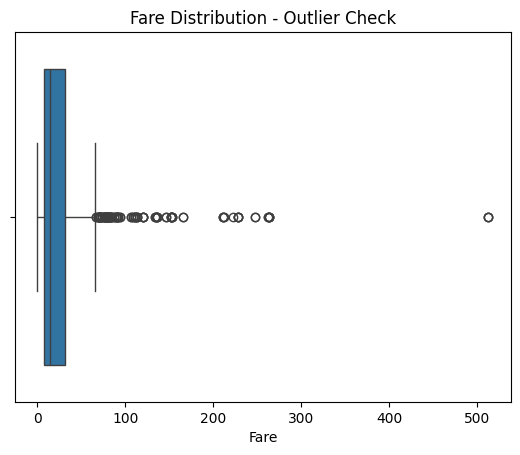

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=df['Fare'])
plt.title('Fare Distribution - Outlier Check')
plt.show()

In [36]:
df.groupby('Pclass')['Fare'].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500


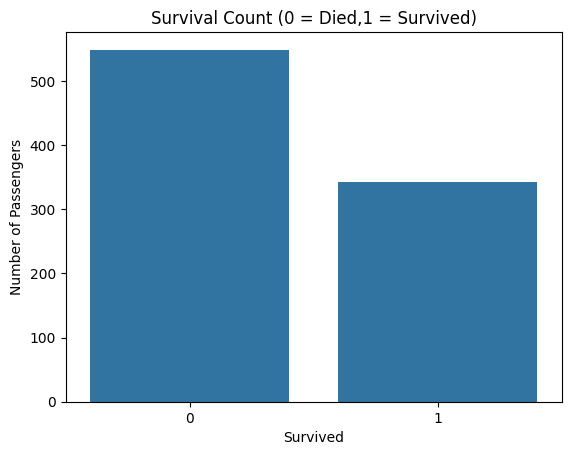

In [37]:
sns.countplot(x='Survived',data=df)
plt.title('Survival Count (0 = Died,1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.show()

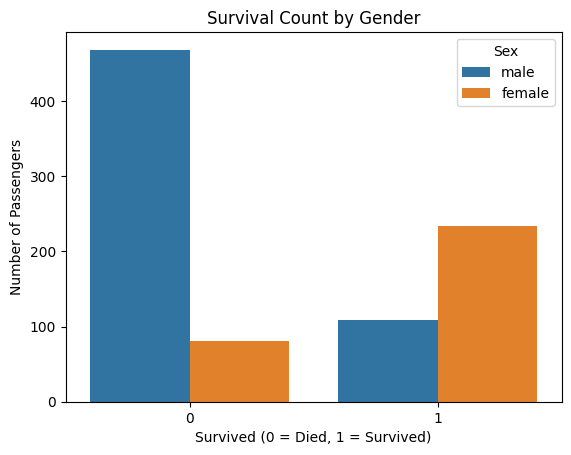

In [38]:
sns.countplot(x='Survived', hue='Sex',data=df)
plt.title('Survival Count by Gender')
plt.xlabel('Survived (0 = Died, 1 = Survived)')
plt.ylabel('Number of Passengers')
plt.show()

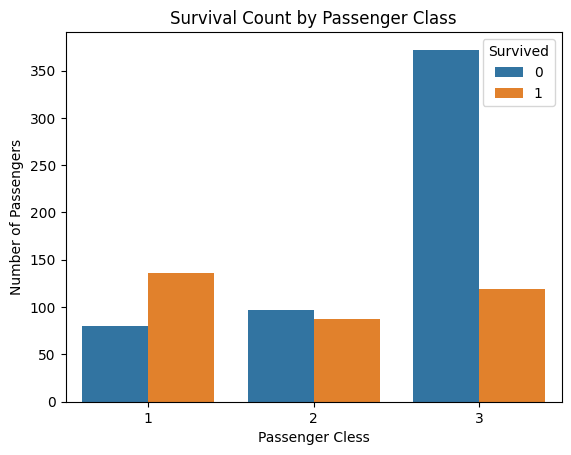

In [39]:
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Cless')
plt.ylabel('Number of Passengers')
plt.show()

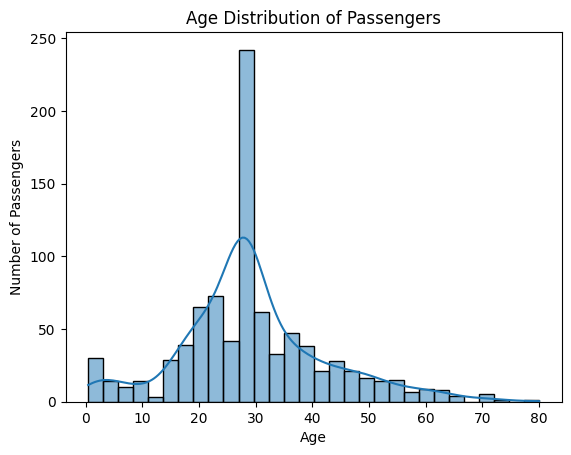

In [40]:
sns.histplot(df['Age'],bins=30,kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

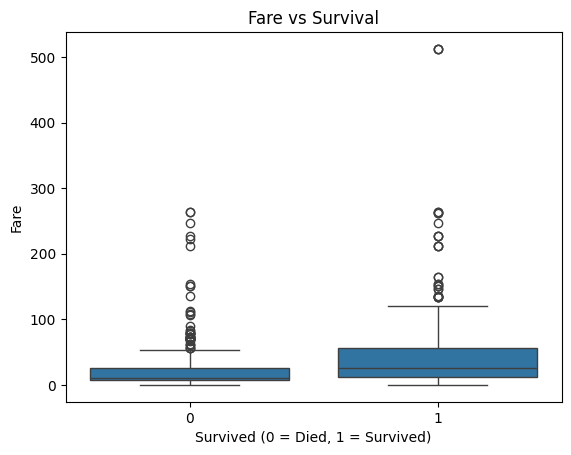

In [42]:
sns.boxplot(x='Survived', y='Fare',data=df)
plt.title('Fare vs Survival')
plt.xlabel('Survived (0 = Died, 1 = Survived)')
plt.ylabel('Fare')
plt.show()

This project analyzes the Titanic passenger dataset to understand who survived and who didn't. The raw data had missing values in Age (177 missing), Cabin (687 missing), and Embarked (2 missing). Since Cabin was missing for over 77% of passengers, it was dropped entirely. Age was filled using the median value, and Embarked was filled using the most common port, since dropping these rows would have lost otherwise complete passenger records.

After cleaning, the analysis showed that most passengers did not survive — roughly 62% died. Gender had the strongest impact on survival: women survived at a much higher rate than men, consistent with the "women and children first" policy. Passenger class also mattered significantly: 1st class passengers, who paid on average 4–6 times more than 3rd class, had noticeably higher survival rates, while most 3rd class passengers died. This suggests wealth and social status directly influenced survival chances.

The age distribution showed most passengers were young adults between 20–40. However, an artificial spike appears around the median age (~28-30) due to the median-fill method used for missing Age values — a limitation worth noting rather than treating the chart as fully accurate.